<a href="https://colab.research.google.com/github/Zuhair0000/TensorFlow-ML-DL-Project-Practice/blob/main/NLP_level_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [3]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [4]:
X = df['review'].values
y = df['sentiment'].values

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ML

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = Pipeline([
    ('vecorizer', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('model', MultinomialNB())
])

In [7]:
model.fit(X_train, y_train)

Pipeline(steps=[('vecorizer',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('model', MultinomialNB())])

In [8]:
y_pred = model.predict(X_test)
y_pred

array(['negative', 'positive', 'negative', ..., 'positive', 'negative',
       'negative'], dtype='<U8')

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

print(f"Classification Report: \n{classification_report(y_test, y_pred)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")

Classification Report: 
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Confusion Matrix: 
[[4209  752]
 [ 739 4300]]


# Deep Learning (TF)

In [10]:
import tensorflow as tf

vocab_size = 10000
sequence_length = 200

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length
)

In [11]:
vectorize_layer.adapt(X_train)

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [13]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_encoded)).shuffle(buffer_size=len(X_train)).batch(64).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_encoded)).batch(64).prefetch(tf.data.AUTOTUNE)

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, ), dtype=tf.string),

    vectorize_layer,

    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
X_train_tensor = tf.convert_to_tensor(X_train, dtype=tf.string)
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.string)

y_train_binary = (y_train == 'positive').astype(float)
y_test_binary = (y_test == 'positive').astype(float)


y_train_tensor = tf.convert_to_tensor(y_train_binary, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test_binary, dtype=tf.float32)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [18]:
history_0 = model.fit(train_ds,
                      validation_data=test_ds,
                      epochs=20,
                      callbacks=[early_stopping])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.7955 - loss: 0.4385 - val_accuracy: 0.8600 - val_loss: 0.3418
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8862 - loss: 0.2935 - val_accuracy: 0.8669 - val_loss: 0.3268
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9054 - loss: 0.2484 - val_accuracy: 0.8692 - val_loss: 0.3168
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9198 - loss: 0.2132 - val_accuracy: 0.8726 - val_loss: 0.3067
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9299 - loss: 0.1847 - val_accuracy: 0.8688 - val_loss: 0.3876
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9413 - loss: 0.1619 - val_accuracy: 0.8747 - val_loss: 0.3882
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9485 - loss: 0.1400 - val_accuracy: 0.8657 - val_loss: 0.4058


In [19]:
history_1 = model.fit(X_train_tensor, y_train_tensor,
                    validation_data=(X_test_tensor, y_test_tensor),
                    epochs=20,
                    batch_size=64,
                    callbacks=[early_stopping])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9294 - loss: 0.1888 - val_accuracy: 0.8613 - val_loss: 0.4072
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9394 - loss: 0.1619 - val_accuracy: 0.8707 - val_loss: 0.3837
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9473 - loss: 0.1424 - val_accuracy: 0.8619 - val_loss: 0.3679


In [20]:
test_loss, test_accuracy = model.evaluate(X_test_tensor, y_test_tensor)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8613 - loss: 0.4072
Final Test Accuracy: 86.13%
Final Test Loss: 0.4072


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


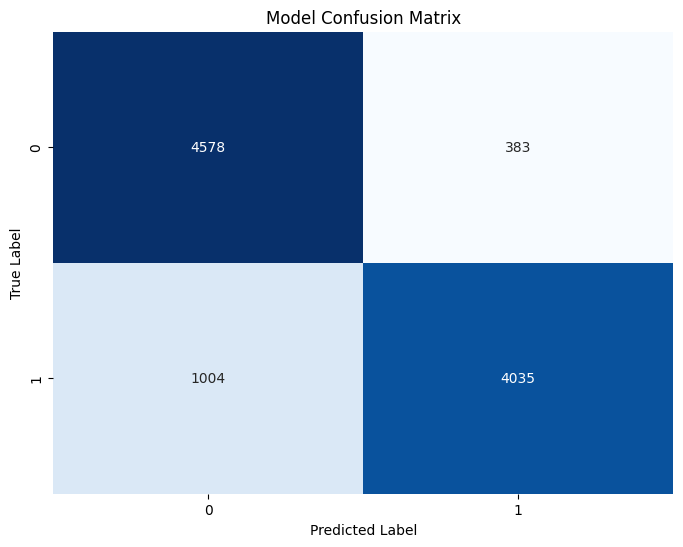

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_probs = model.predict(X_test_tensor)

y_pred_classes = (y_pred_probs > 0.5).astype(int)

y_true = y_test_tensor

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Deep Learning (PyTorch)

In [22]:
import torch
from torch.utils.data import Dataset

In [23]:
class TextClassificationDataset(Dataset):
  def __init__(self, text, labels):
    self.texts = text
    self.labels = labels

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    single_text = self.texts[idx]

    single_label = self.labels[idx]

    return single_text, single_label

In [26]:
from torch.utils.data import DataLoader
X_train_seq = vectorize_layer(X_train).numpy()
X_test_seq = vectorize_layer(X_test).numpy()

train_ds = TextClassificationDataset(X_train_seq, y_train_encoded)
test_ds = TextClassificationDataset(X_test_seq, y_test_encoded)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [27]:
import torch.nn as nn

class TextClassifier(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_dim):

    super(TextClassifier, self).__init__()

    self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

    self.dropout1 = nn.Dropout(p=0.4)

    self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, batch_first=True)

    self.dropout2 = nn.Dropout(p=0.4)

    self.fc = nn.Linear(in_features=hidden_dim, out_features=1)

  def forward(self, x):
    x = self.embedding(x)
    x = self.dropout1(x)

    lstm_out, _ = self.lstm(x)
    last_time_step = lstm_out[:, -1, :]

    x = self.dropout2(last_time_step)
    x = self.fc(x)

    return torch.sigmoid(x)

In [29]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

vocab_size=10000
embedding_dim=64
hidden_dim=64

model = TextClassifier(vocab_size, embedding_dim, hidden_dim)
model = model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs=20

for epoch in range(epochs):
  total_loss=0

  for batch_texts, batch_labels in train_loader:

    batch_texts = batch_texts.to(device)
    batch_labels = batch_labels.to(device).float().unsqueeze(1)

    optimizer.zero_grad()

    predictions = model(batch_texts)

    loss = criterion(predictions, batch_labels)

    loss.backward()

    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss / len(train_loader):.4f}")


Using device: cuda
Epoch 1/20 | Loss: 0.6944
Epoch 2/20 | Loss: 0.6913
Epoch 3/20 | Loss: 0.6908
Epoch 4/20 | Loss: 0.6730
Epoch 5/20 | Loss: 0.6499
Epoch 6/20 | Loss: 0.5958
Epoch 7/20 | Loss: 0.5043
Epoch 8/20 | Loss: 0.4239
Epoch 9/20 | Loss: 0.3788
Epoch 10/20 | Loss: 0.3485
Epoch 11/20 | Loss: 0.3264
Epoch 12/20 | Loss: 0.3095
Epoch 13/20 | Loss: 0.2928
Epoch 14/20 | Loss: 0.2778
Epoch 15/20 | Loss: 0.2640
Epoch 16/20 | Loss: 0.2544
Epoch 17/20 | Loss: 0.2429
Epoch 18/20 | Loss: 0.2357
Epoch 19/20 | Loss: 0.2290
Epoch 20/20 | Loss: 0.2162


In [30]:
model.eval()

correct_predictions = 0
total_predictions = 0

with torch.no_grad():

  for batch_texts, batch_labels in test_loader:
    batch_texts = batch_texts.to(device)
    batch_labels = batch_labels.to(device).float().unsqueeze(1)

    predictions = model(batch_texts)

    rounded_preds = torch.round(predictions)

    correct_predictions += (rounded_preds == batch_labels).sum().item()
    total_predictions += batch_labels.size(0)

accuracy = correct_predictions / total_predictions
print(f"PyTorch Test Accuracy: {accuracy * 100:.2f}%")

PyTorch Test Accuracy: 88.47%
